<a href="https://colab.research.google.com/github/isabe11asmith/NEUR-3002/blob/main/ICA_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Actual wind direction: 160 degrees
Decoded wind direction: 160.0 degrees
Neuron 1 - Preferred direction: 0 degrees | Firing rate: 0.0 spikes/sec
Neuron 2 - Preferred direction: 45 degrees | Firing rate: 0.0 spikes/sec
Neuron 3 - Preferred direction: 90 degrees | Firing rate: 17.1 spikes/sec
Neuron 4 - Preferred direction: 135 degrees | Firing rate: 45.32 spikes/sec
Neuron 5 - Preferred direction: 180 degrees | Firing rate: 46.98 spikes/sec
Neuron 6 - Preferred direction: 225 degrees | Firing rate: 21.13 spikes/sec
Neuron 7 - Preferred direction: 270 degrees | Firing rate: 0.0 spikes/sec
Neuron 8 - Preferred direction: 315 degrees | Firing rate: 0.0 spikes/sec


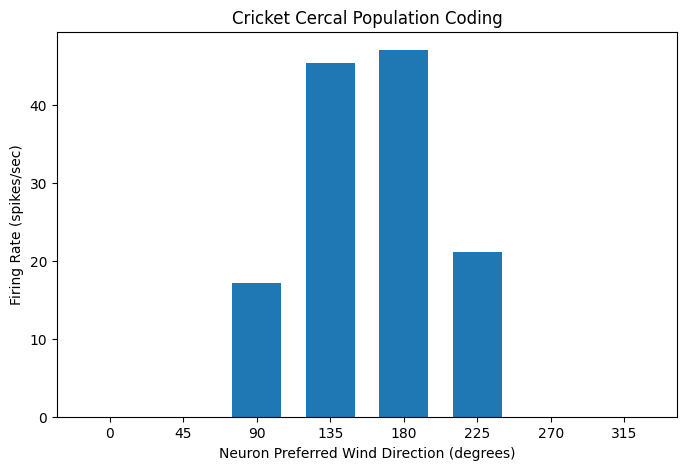

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Population Coding: Cricket Cerci
# -----------------------------------

# Preferred wind directions of 8 sensory neurons (degrees)
preferred_directions = np.arange(0, 360, 45)

# Actual direction of the wind
wind_direction = 160

# Maximum firing rate (spikes/sec)
max_firing_rate = 50

# Calculate the firing rate of each neuron
# Neurons fire most strongly when wind matches their preferred direction
firing_rates = []

for preferred_direction in preferred_directions:

    # Difference between wind direction and preferred direction
    angle_difference = np.radians(wind_direction - preferred_direction)

    # Cosine tuning curve
    firing_rate = max_firing_rate * max(0, np.cos(angle_difference))

    firing_rates.append(firing_rate)

firing_rates = np.array(firing_rates)


# -----------------------------------
# Decode wind direction
# -----------------------------------

# Convert each neuron's preferred direction into a vector
x = np.sum(firing_rates * np.cos(np.radians(preferred_directions)))
y = np.sum(firing_rates * np.sin(np.radians(preferred_directions)))

# Estimate wind direction from population activity
decoded_direction = np.degrees(np.arctan2(y, x))

# Convert negative angles to 0-360 degrees
if decoded_direction < 0:
    decoded_direction += 360


# -----------------------------------
# Print results
# -----------------------------------

print("Actual wind direction:", wind_direction, "degrees")
print("Decoded wind direction:", round(decoded_direction, 2), "degrees")

for i in range(len(preferred_directions)):
    print(
        "Neuron", i + 1,
        "- Preferred direction:", preferred_directions[i],
        "degrees | Firing rate:", round(firing_rates[i], 2),
        "spikes/sec"
    )


# -----------------------------------
# Plot population activity
# -----------------------------------

plt.figure(figsize=(8, 5))

plt.bar(preferred_directions, firing_rates, width=30)

plt.xlabel("Neuron Preferred Wind Direction (degrees)")
plt.ylabel("Firing Rate (spikes/sec)")
plt.title("Cricket Cercal Population Coding")

plt.xticks(preferred_directions)

plt.show()